In [49]:
import qutip as qt
from qutip import tensor
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from quantum_logical.operators import selective_destroy
from scipy.optimize import curve_fit

In [50]:
# generating parameters and creating initial state
# T1 = 50
# T2 = 25
T1 = 1
T2 = .5
N = 5
dim = 2
trotter_dt = .0001
# psi0 = qt.tensor((qt.basis(dim, 1) + qt.basis(dim, 0)).unit(), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
# psi0 = qt.basis(dim, 1)
# rho0 = psi0 * psi0.dag()
amp_damp_channel = AmplitudeDamping(T1, num_qubits=N, hilbert_space_dim=dim)
phase_damp_channel = PhaseDamping(T1, T2, num_qubits=N, hilbert_space_dim=dim)
# trotter = TrotterGroup(
#     continuous_operators=[amp_damp_channel, phase_damp_channel],
#     trotter_dt=trotter_dt,
# )
trotter = TrotterGroup(
    continuous_operators=[amp_damp_channel],
    trotter_dt=trotter_dt,
)


# qt.Qobj(amp_damp_channel._create_single_qubit_operators(T1=1)[1])
# identity = qt.qeye(dim ** N)

In [51]:
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

x_gate = qt.Qobj([[0, 1],[1, 0]])

C:\Users\girgi\AppData\Local\Temp\ipykernel_3124\2826208940.py:2: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_3124\2826208940.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_3124\2826208940.py:5: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
fr

In [52]:
# creating the initial state and encoding it 
psi0 = qt.tensor((qt.basis(dim, 1)).unit(), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
# psi0 = qt.tensor((qt.basis(dim, 0)).unit(), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0), qt.basis(dim, 0))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
# trace out the ancillas to get the true result
rho_encoded_traced = qt.ptrace(rho_encoded, [0, 1, 2])
# the correct initial state has been prepared 
rho_encoded_traced 
# store the states and the fidelities that come out
states = []
fids = []
states.append(rho_encoded)
fids.append(qt.fidelity(rho_encoded_traced, rho_encoded_traced))

In [53]:
# states_idle = []
# fids_idle = []
# time_full_idle = np.linspace(0.0001, .5, 50)
# for i in tqdm(time_full_idle):
#     rho_full_idle = trotter.apply(rho_encoded, duration = i, discrete_unitary=tensor([qt.qeye(dim)] * 5))
#     states_idle.extend(rho_full_idle)
#     a = qt.ptrace(rho_full_idle[-1], [0,1,2])
#     fids_idle.append(qt.fidelity(a, rho_encoded_traced))


In [54]:

# # plot the idle fid 
# fig, ax = plt.subplots()
# ax.plot(time_full_idle, fids_idle)

# # fit the plot to get a T1
# def function_fit(t, b):
#     return np.exp(-t / b)

# parameters, covariance = curve_fit(function_fit, time_full_idle, fids_idle)

# fit_func = function_fit(time_full_idle, parameters[0])
# ax.plot(time_full_idle, fit_func, color = "black", linestyle = "-", label = "fitted line")
# # plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


# T1_stabilizer = parameters[0]
# print(parameters[0]) 

In [55]:
# run the circuit 
initial_time = .8
initial_state_relax = trotter.apply(rho_encoded, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
for i in range(len(initial_state_relax)):
    a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
    states.append(initial_state_relax[i])
    fids.append(qt.fidelity(a, rho_encoded_traced))

# now apply the cnots to the circuit 
cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3

syndrome_time = .0001
# after_syndrome_extraction = trotter.apply(initial_state_relax[-1], duration= syndrome_time, discrete_unitary=cnot_gate_overall)
after_syndrome_extraction = trotter.apply(initial_state_relax[-1], duration= syndrome_time, discrete_unitary=cnot_gate_overall)
for i in range(len(after_syndrome_extraction)):
    a = qt.ptrace(after_syndrome_extraction[i], [0, 1, 2])
    states.append(after_syndrome_extraction[i])
    fids.append(qt.fidelity(a, rho_encoded_traced))

In [56]:
qt.ptrace(initial_state_relax[-1], [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0.00323096 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.01862656 0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.01862656 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.10736668 0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.01862656 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.10736668
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.10736668 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.61878933]]

In [57]:
# projective measurement 
projection_operator_00 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag()))
projection_operator_01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag()))
projection_operator_10 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())) 
projection_operator_11 = qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag()))


In [58]:
a = (projection_operator_00 * after_syndrome_extraction[-1]).tr()
b = (projection_operator_01 * after_syndrome_extraction[-1]).tr()
c = (projection_operator_10 * after_syndrome_extraction[-1]).tr()
d = (projection_operator_11 * after_syndrome_extraction[-1]).tr()

In [59]:
# apply the recovery gate
# # measurement step is instantaneous 
rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag())
rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())
rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())
rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

# rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() 
# rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() 
# rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() 
# rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() 
# now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))

In [60]:
# recovery algorithm
# correction_op = (r00 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag())).full()) +
#                  r01 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag())).full()) +
#                  r10 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())).full()) +
#                  r11 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag())).full())
# )

recovery_time = .0001
# measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
# there needs to be more done for rho encoded
# states.extend(recovery1)
# fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

# have to add them back to get the overall density matrix 
for i in range(len(recovery4)):
    total_state = (a * recovery1[i] + 
                   b * recovery2[i] + 
                   c * recovery3[i] + 
                   d * recovery4[i])
    # total_state = (recovery1[i] + 
    #                recovery2[i] + 
    #                recovery3[i] + 
    #                recovery4[i])
    # total_state = (qt.ptrace(rho00, [0,1,2]).tr() * recovery1[i])
    total_state_normal = total_state / total_state.tr()
    total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
    states.append(total_state_normal)
    fids.append(qt.fidelity(total_state_trace, rho_encoded_traced))

# total_time = recovery_time + syndrome_time + initial_time
total_time = recovery_time + syndrome_time

In [61]:
# trace out the ancillas
state_new = []
for i in range(len(states)):
    state_new.append(qt.ptrace(states[i], [0, 1, 2]))
time = np.linspace(0, total_time, len(states))

Text(0.5, 0, 'time (μs)')

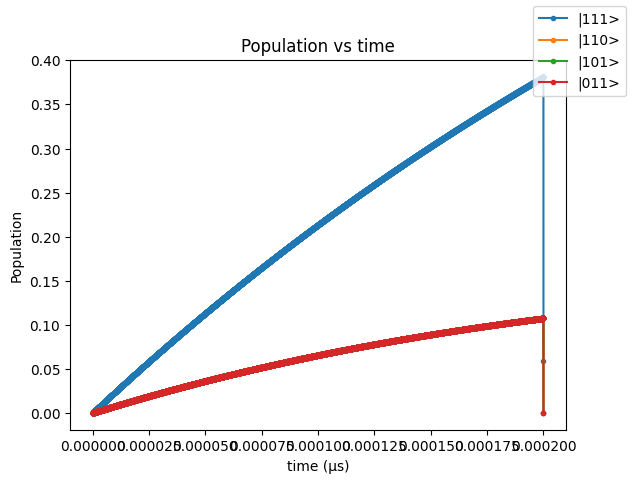

In [62]:
# graph the results
fig, ax = plt.subplots()
# for i in range(dim ** 3):
af = [7,6,5,3]
bf = ["|111>", "|110>", "|101>", "|011>"]
for i in range(len(af)):
    data = []
    for j in range(len(state_new)):
    #     if i != 7:
    #         data.append(state_new[j][i, i])
    #     elif i == 7:
    #         data.append(1 - state_new[j][i, i])
        if af[i] != 7:
            data.append(state_new[j][af[i],af[i]])
        elif af[i] == 7:
            data.append(1 - state_new[j][af[i],af[i]])
    
    ax.plot(time, data, label = bf[i], marker = ".")


fig.legend(loc = "upper right")
ax.set_title("Population vs time")
ax.set_ylabel("Population")
ax.set_xlabel(u"time (\u03bcs)")

# stages = [.4, .42]
# for i in stages:
#     ax.axvline(x=i, color='grey', linestyle='--')

In [63]:
data[-1]

(1.6669200924373777e-05+0j)

In [64]:
(0.002578242826907662+0j)

(0.002578242826907662+0j)

0j
0j
0j
0j
0j
0j
0j
0j


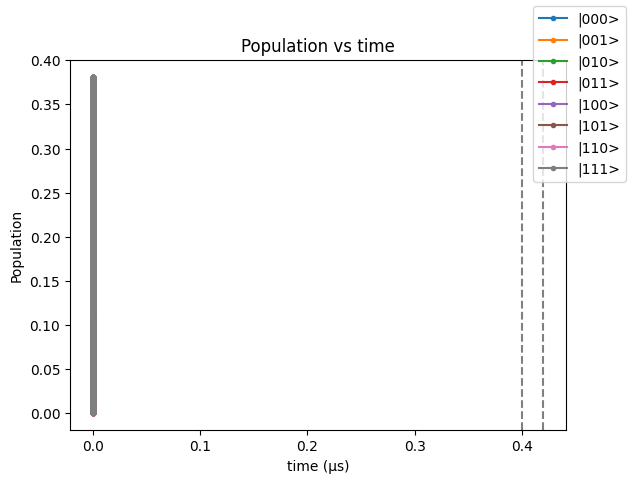

In [65]:
# graph the results
fig, ax = plt.subplots()
# for i in range(dim ** 3):
bf = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
for i in range(dim ** 3):
    data = []
    for j in range(len(state_new)):
    #     if i != 7:
    #         data.append(state_new[j][i, i])
    #     elif i == 7:
    #         data.append(1 - state_new[j][i, i])
        if i != 7:
            data.append(state_new[j][i,i])
        elif i == 7:
            data.append(1 - state_new[j][i,i])
    print(min(data))
    ax.plot(time, data, label = bf[i], marker = ".")


fig.legend(loc = "upper right")
ax.set_title("Population vs time")
ax.set_ylabel("Population")
ax.set_xlabel(u"time (\u03bcs)")

# stages = [.4, .41]
stages = [.4, .42]
for i in stages:
    ax.axvline(x=i, color='grey', linestyle='--')

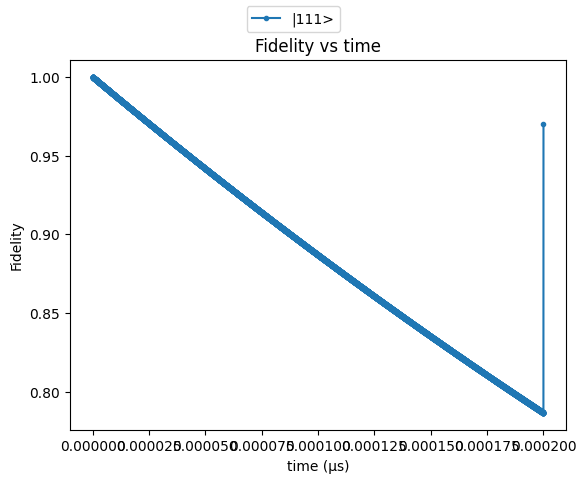

In [66]:
# fidelity plots 
fig, ax = plt.subplots()
ax.plot(time, fids, label = "|111>", marker = ".")

ax.set_title("Fidelity vs time")
ax.set_ylabel("Fidelity")
ax.set_xlabel(u"time (\u03bcs)")
fig.legend(loc = "upper center")

# stages = [.4, .41]
# stages = [.4, .42]
# for i in stages:
#     ax.axvline(x=i, color='grey', linestyle='--')

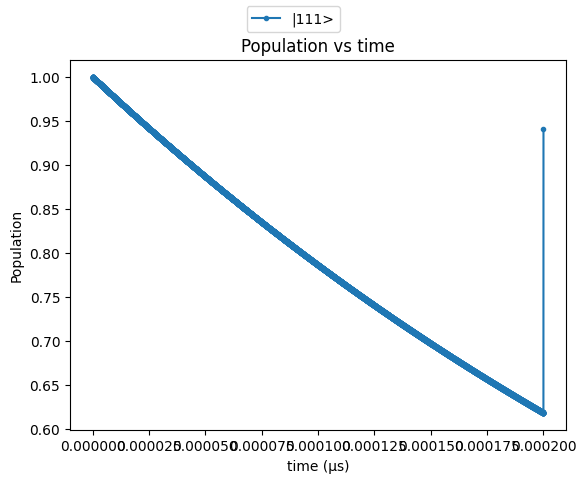

In [67]:
fig, ax = plt.subplots()
data = []
for i in range(len(state_new)):
    data.append(state_new[i][7, 7])
ax.plot(time, data, label = "|111>", marker = ".")

ax.set_title("Population vs time")
ax.set_ylabel("Population")
ax.set_xlabel(u"time (\u03bcs)")
fig.legend(loc = "upper center")

# stages = [.4, .41]
# stages = [.4, .42]
# for i in stages:
#     ax.axvline(x=i, color='grey', linestyle='--')

In [20]:
(0.9583928216658422+0j)
(0.978121632870449+0j)
(0.9791228171301505+0j)
(0.9817112750543882+0j)

(0.9817112750543882+0j)

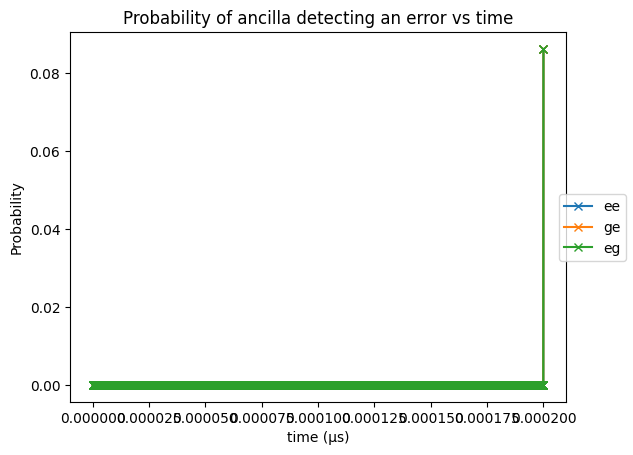

In [21]:
# getting the probability that the ancillas measure a syndrome 
# states is the function that holds the states as a function o
prob_gg = []
prob_ge = []
prob_eg = []
prob_ee = []

state_gg = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)).dag()
state_ge = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)).dag()
state_eg = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)).dag()
state_ee = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)).dag()
for i in states:
    reduced_state = qt.ptrace(i, [3, 4])
    prob_gg.append((state_gg * reduced_state).tr())
    prob_ge.append((state_ge * reduced_state).tr())
    prob_eg.append((state_eg * reduced_state).tr())
    prob_ee.append((state_ee * reduced_state).tr())

probs = [prob_gg, prob_ge, prob_eg, prob_ee]

fig, ax = plt.subplots()
# for i in probs:
#     ax.plot(time, i)
# ax.plot(time, prob_ge)
# ax.plot(time, prob_eg)
ax.plot(time, prob_ee, marker = "x", label = "ee")
ax.plot(time, prob_ge, marker = "x", label = "ge")
ax.plot(time, prob_eg, marker = "x", label = "eg")
    
# seems reasonable 
ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Probability")
ax.set_title("Probability of ancilla detecting an error vs time")
fig.legend(loc = "center right")

# start the analysis  

In [22]:
# make measurement as close to instant as possible and scan over all of the cnot times this should not be that hard 
# can make the cnot fully instant not hard
# removing errors from the ancillas 
fiddy = []
def analysis_over_diff_cnot_times(time_idle):
    states = []
    fids = []
    states.append(rho_encoded)
    fids.append(qt.fidelity(rho_encoded_traced, rho_encoded_traced))
    fiddy.append(fids[-1])

    initial_time = time_idle
    initial_state_relax = trotter.apply(rho_encoded, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
    for i in range(len(initial_state_relax)):
        a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
        states.append(initial_state_relax[i])
        fids.append(qt.fidelity(a, rho_encoded_traced))


    cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3

    syndrome_time = .0001
    # after_syndrome_extraction = trotter.apply(initial_state_relax[-1], duration= syndrome_time, discrete_unitary=cnot_gate_overall)
    after_syndrome_extraction = trotter.apply(initial_state_relax[-1], duration= syndrome_time, discrete_unitary=cnot_gate_overall)
    for i in range(len(after_syndrome_extraction)):
        a = qt.ptrace(after_syndrome_extraction[i], [0, 1, 2])
        states.append(after_syndrome_extraction[i])
        fids.append(qt.fidelity(a, rho_encoded_traced))


    a = (projection_operator_00 * after_syndrome_extraction[-1]).tr()
    b = (projection_operator_01 * after_syndrome_extraction[-1]).tr()
    c = (projection_operator_10 * after_syndrome_extraction[-1]).tr()
    d = (projection_operator_11 * after_syndrome_extraction[-1]).tr()

    # apply the recovery gate
    # # measurement step is instantaneous 
    rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag())
    rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())
    rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())
    rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

    # rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() 
    # rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() 
    # rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() 
    # rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() 
    # now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
    # correction_operators
    r00 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))

    # recovery algorithm
    # correction_op = (r00 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag())).full()) +
    #                  r01 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag())).full()) +
    #                  r10 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())).full()) +
    #                  r11 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag())).full())
    # )

    recovery_time = .0001
    # measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
    recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
    # there needs to be more done for rho encoded
    # states.extend(recovery1)
    # fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
    recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
    recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
    recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

    # have to add them back to get the overall density matrix 
    for i in range(len(recovery4)):
        total_state = (a * recovery1[i] + 
                    b * recovery2[i] + 
                    c * recovery3[i] + 
                    d * recovery4[i])
        # total_state = (recovery1[i] + 
        #                recovery2[i] + 
        #                recovery3[i] + 
        #                recovery4[i])
        # total_state = (qt.ptrace(rho00, [0,1,2]).tr() * recovery1[i])
        total_state_normal = total_state / total_state.tr()
        total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
        states.append(total_state_normal)
        fids.append(qt.fidelity(total_state_trace, rho_encoded_traced))
        fiddy.append(fids[-1])

    # total_time = recovery_time + syndrome_time + initial_time
    # total_time = recovery_time + syndrome_time
    return time_idle, fids[-1]


In [23]:
times_idle = np.linspace(0.0001, .5, 50)
# measurment is instant here 
times_list = []
fids_list = []
for i in tqdm(times_idle):
    a, b = analysis_over_diff_cnot_times(time_idle=i)
    times_list.append(a)
    fids_list.append(b)

100%|██████████| 50/50 [01:44<00:00,  2.10s/it]


Text(0.5, 1.0, 'Fidelity vs idle time(instant CNOT)')

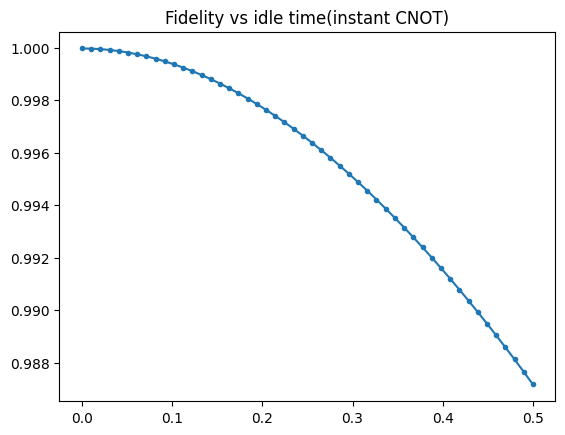

In [24]:
fig, ax = plt.subplots()
ax.plot(times_list, fids_list, marker = ".")
ax.set_title("Fidelity vs idle time(instant CNOT)")

In [25]:
# taking into account ancilla error 
def analysis_over_diff_cnot_times(time_cnot):
    states = []
    fids = []
    states.append(rho_encoded)
    fids.append(qt.fidelity(rho_encoded_traced, rho_encoded_traced))

    initial_time = .0001
    initial_state_relax = trotter.apply(rho_encoded, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
    for i in range(len(initial_state_relax)):
        a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
        states.append(initial_state_relax[i])
        fids.append(qt.fidelity(a, rho_encoded_traced))


    cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3

    syndrome_time = time_cnot

    after_syndrome_extraction = trotter.apply(initial_state_relax[-1], duration= syndrome_time, discrete_unitary=cnot_gate_overall)
    for i in range(len(after_syndrome_extraction)):
        a = qt.ptrace(after_syndrome_extraction[i], [0, 1, 2])
        states.append(after_syndrome_extraction[i])
        fids.append(qt.fidelity(a, rho_encoded_traced))


    a = (projection_operator_00 * after_syndrome_extraction[-1]).tr()
    b = (projection_operator_01 * after_syndrome_extraction[-1]).tr()
    c = (projection_operator_10 * after_syndrome_extraction[-1]).tr()
    d = (projection_operator_11 * after_syndrome_extraction[-1]).tr()

    # apply the recovery gate
    # # measurement step is instantaneous 
    rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag())
    rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())
    rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())
    rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

    
    r00 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))

    

    recovery_time = .0001

    recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)

    recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
    recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
    recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

    # have to add them back to get the overall density matrix 
    for i in range(len(recovery4)):
        total_state = (a * recovery1[i] + 
                    b * recovery2[i] + 
                    c * recovery3[i] + 
                    d * recovery4[i])

        total_state_normal = total_state / total_state.tr()
        total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
        states.append(total_state_normal)
        fids.append(qt.fidelity(total_state_trace, rho_encoded_traced))
        fiddy.append(fids[-1])

    return time_cnot, fids[-1]

In [26]:
cnot_times = np.linspace(0.0001, .5, 50)
# measurment is instant here 
times_list = []
fids_list_ancilla_error = []
for i in tqdm(cnot_times):
    a, b = analysis_over_diff_cnot_times(time_cnot=i)
    times_list.append(a)
    fids_list_ancilla_error.append(b)

100%|██████████| 50/50 [01:47<00:00,  2.14s/it]


Text(0.5, 1.0, 'Fidelity vs CNOT execution time')

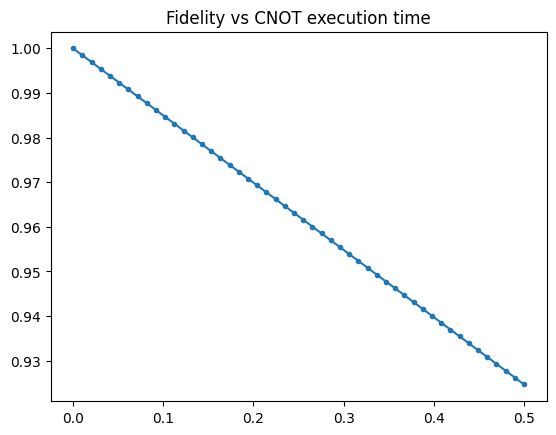

In [27]:
fig, ax = plt.subplots()
ax.plot(times_list, fids_list_ancilla_error, marker = ".")
ax.set_title("Fidelity vs CNOT execution time")

Text(0.5, 1.0, 'Fidelity vs CNOT execution time as compared to instant CNOT')

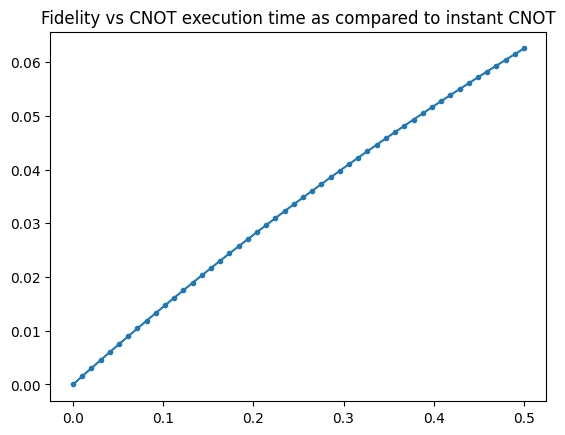

In [28]:
# subtract the two from eachother to see how much the ancilla error contributes
# this can be done for different t1s to get a better idea of the error contribution of the ancilla as a function of cnot time 
fids_comparison = []
for i in range(len(fids_list_ancilla_error)):
    fids_comparison.append(fids_list[i] - fids_list_ancilla_error[i])

fig, ax = plt.subplots()
ax.plot(times_list, fids_comparison, marker = ".")
ax.set_title("Fidelity vs CNOT execution time as compared to instant CNOT")

In [29]:
# do this for an instant CNOT and then some time recovery to get an idea of the theoretical limit 
# in order for this analysis to be useful you will need a section that calculates the t1 before jumping into all of this because otherwise this does not make any sense to compare 
# if you dont know the limit from the t1

# stop the analysis with plots 

In [ ]:
compare_state = []
compare_fids = []
# total_time = 500
total_time = 195.99
rho_plot = trotter.apply(rho_encoded, duration=total_time, discrete_unitary=qt.qeye(dim  ** N))
for i in range(len(rho_plot)):
    a = qt.ptrace(rho_plot[i], [0, 1, 2])
    compare_state.append(a)
    compare_fids.append(qt.fidelity(a, rho_encoded_traced))

In [ ]:
time = np.linspace(0, total_time, len(compare_state))

In [ ]:
fig, ax = plt.subplots()
# can change the data in the ax function to compare fids in order to get results for the fids
data = []
for i in range(len(compare_state)):
    data.append(compare_state[i][7, 7])
ax.plot(time, data, label = "|111>", marker = ".")

ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Population")
ax.set_title("Population vs time")
# label this as idle 

fig.legend(loc = "upper center")

# fitting the data
def function_fit(t, b):
    return np.exp(-t / b)

parameters, covariance = curve_fit(function_fit, time, data)

fit_func = function_fit(time, parameters[0])
ax.plot(time, fit_func, color = "black", linestyle = "-", label = "fitted line")
# plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


T1_idle = parameters[0]
print(parameters[0]) 

In [ ]:
# make a fidelity vs iterations for these it should not be too hard make a stabilizer function and take data from that and plot it 
# this may be easy to do with fidelity instead of the state and this may give a result that makes sense 
def stabilizer(initial_state, check_state, time_list):
    fids = []
    states = []

    # # run the circuit 
    # initial_time = time_list[0]
    # initial_state_relax = trotter.apply(initial_state, duration=initial_time, discrete_unitary=qt.qeye(dim ** N))
    # for i in range(len(initial_state_relax)):
    #     a = qt.ptrace(initial_state_relax[i], [0, 1, 2])
    #     states.append(initial_state_relax[i])
    #     fids.append(qt.fidelity(a, check_state))

    # now apply the cnots to the circuit 
    cnot_gate_overall = cnot6 * cnot5 * cnot4 * cnot3

    syndrome_time = time_list[0]
    after_syndrome_extraction = trotter.apply(initial_state, duration= syndrome_time, discrete_unitary=cnot_gate_overall)
    for i in range(len(after_syndrome_extraction)):
        a = qt.ptrace(after_syndrome_extraction[i], [0, 1, 2])
        states.append(after_syndrome_extraction[i])
        fids.append(qt.fidelity(a, check_state))


    # apply the recovery gate
    # measurement step is instantaneous 
    rho00 = projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag() / np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag())
    rho01 = projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag() / np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag())
    rho10 = projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag() / np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag())
    rho11 = projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag() / np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag())

    # now you have to trotterize all of these separately and then bring them back together this is a way to get around this but roger thinks its dumb 
    # correction_operators
    r00 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))


    # recovery algorithm
    # correction_op = (r00 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0))).dag())).full()) +
    #                 r01 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1))).dag())).full()) +
    #                 r10 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0))).dag())).full()) +
    #                 r11 * qt.Qobj(qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * (qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1))).dag())).full())
    # )

    recovery_time = time_list[1]
    # measurement = trotter.apply(final_state, duration=measurement_dur, discrete_unitary=qt.qeye(dim ** N))
    recovery1 = trotter.apply(rho00, duration=recovery_time, discrete_unitary=r00)
    # states.extend(recovery1)
    # fids.append(qt.fidelity(qt.ptrace(recovery1[-1], [0, 1, 2]), rho_encoded_traced))
    recovery2 = trotter.apply(rho01, duration=recovery_time, discrete_unitary=r01)
    recovery3 = trotter.apply(rho10, duration=recovery_time, discrete_unitary=r10)
    recovery4 = trotter.apply(rho11, duration=recovery_time, discrete_unitary=r11)

    # have to add them back to get the overall density matrix 
    for i in range(len(recovery1)):
        total_state = (np.trace(projection_operator_00 * after_syndrome_extraction[-1] * projection_operator_00.dag()) * recovery1[i] + 
                    np.trace(projection_operator_01 * after_syndrome_extraction[-1] * projection_operator_01.dag()) * recovery2[i] + 
                    np.trace(projection_operator_10 * after_syndrome_extraction[-1] * projection_operator_10.dag()) * recovery3[i] + 
                    np.trace(projection_operator_11 * after_syndrome_extraction[-1] * projection_operator_11.dag()) * recovery4[i])
        total_state_normal = total_state / np.trace(total_state)
        total_state_trace = qt.ptrace(total_state_normal, [0, 1, 2])
        states.append(total_state_normal)
        fids.append(qt.fidelity(total_state_trace, check_state))

    

    return states, fids

In [ ]:
result_states = []
result_fids = []
# result_fids.append(1)

time_list = [.4, .05]

# doing stabilizers for multiple iterations
iterations = 417
# iterations = 726
iter_list = [] # for graphing purposes 

# building the data
for i in tqdm(range(iterations)):
    iter_list.append(i)
    a, b = stabilizer(initial_state=rho_encoded, check_state=rho_encoded_traced, time_list=time_list)
    c = b[-1]
    result_states.extend(a)
    result_fids.append(c)
    rho_encoded = result_states[-1]

In [ ]:
# create the list of time for the amount of iterations
total_time = iterations * sum(time_list)

time_plot = np.linspace(0, total_time, len(result_states))

# analyze the data
plotted_fids = []
for i in range(int(len(result_fids) / 4)):
    plotted_fids.append(result_fids[i * 4 + 3])  

# trace out the ancillas
state_sim = []
for i in range(len(result_states)):
    state_sim.append(qt.ptrace(result_states[i], [0, 1, 2]))

In [ ]:
# state vs time 
fig, ax = plt.subplots()
datas = []
for j in range(len(state_sim)):
    datas.append(np.real(state_sim[j][7, 7]))    
ax.plot(time_plot, datas, label = "|111>", marker = ".")

ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Population")
ax.set_title("Population vs time")
# label this as idle 

fig.legend(loc = "upper center")

# fitting the data
def function_fit(t, b):
    return np.exp(-t / b)

parameters, covariance = curve_fit(function_fit, time_plot, datas)

fit_func = function_fit(time_plot, parameters[0])
ax.plot(time_plot, fit_func, color = "black", linestyle = "-", label = "fitted line")
# plt.plot(time_idle, datas, color = "orange", marker = ".", alpha = 0.01)


T1_stabilizer = parameters[0]
print(parameters[0]) 

In [ ]:
beta = T1_stabilizer / T1_idle
beta

In [ ]:
# fidelity vs iterations
fig, ax = plt.subplots()
datas = []
# for j in range(len(state_sim)):
#     datas.append(np.real(state_sim[j][7, 7]))    
ax.plot(iter_list, result_fids, label = "|111>", marker = ".")

ax.set_xlabel("Number of iterations")
ax.set_ylabel("Fidelity")
ax.set_title("Fidelity vs number of iterations")

fig.legend(loc = "upper center")

In [ ]:
result_fids[-1]

In [ ]:
fig, ax = plt.subplots()
datas = []
# for j in range(len(state_sim)):
#     datas.append(np.real(state_sim[j][7, 7]))    
ax.plot(time, compare_fids, label = "|111>", marker = ".")
ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Fidelity")
ax.set_title("Fidelity vs time")
# label this as idle 

fig.legend(loc = "upper center")